<div dir="rtl" align="right">

### سؤال هفتم: بررسی افزایش قیمت اسمی و واقعی ملک در سال‌های ۱۴۰۰ تا ۱۴۰۳

در سؤال هفتم از بخش **آمار توصیفی**، افزایش قیمت **اسمی** و **واقعی** ملک در سال‌های ۱۴۰۰ تا ۱۴۰۳ مورد بررسی قرار گرفته است.

برای بررسی این موضوع، محاسبات را به دو روش انجام دادیم؛ یک بار با استفاده از **میانگین قیمت** و بار دیگر با استفاده از **میانه قیمت**. به این ترتیب، تغییرات قیمت در طول این سال‌ها از هر دو منظر بررسی شد.

نکته مهم در تفسیر نتایج این است که تعداد آگهی‌های دارای **قیمت فروش** در سال‌های ۱۴۰۰ و ۱۴۰۱ بسیار کم بوده است. بنابراین، مقادیر به‌دست‌آمده برای این دو سال، به‌ویژه میانگین قیمت، ممکن است نماینده مناسبی از سطح واقعی قیمت بازار نباشند.

به همین دلیل، در نتایج مشاهده می‌شود که از سال ۱۴۰۱ به ۱۴۰۲، **میانگین قیمت اسمی کاهش پیدا می‌کند**. این کاهش لزوماً به معنای کاهش واقعی قیمت ملک در بازار نیست و می‌تواند ناشی از **تعداد بسیار کم آگهی‌های دارای قیمت فروش در سال ۱۴۰۱** و در نتیجه، تأثیرپذیری زیاد میانگین از نمونه محدود موجود باشد.

برای محاسبه **قیمت واقعی**، با توجه به اینکه داده مشخصی برای نرخ تورم سالانه در اختیار نداشتیم، نرخ تورم سالانه را برای تمامی سال‌های مورد بررسی **۵۰ درصد** در نظر گرفتیم و بر اساس آن قیمت‌های اسمی را به قیمت واقعی تبدیل کردیم.

در نهایت، تغییرات قیمت اسمی و واقعی ملک در بازه سال‌های ۱۴۰۰ تا ۱۴۰۳، هم بر اساس **میانگین** و هم بر اساس **میانه** محاسبه و بررسی شد.

</div>



In [1]:
import jdatetime
import pandas as pd


#   پایپ‌لاین
def clean_columns(df):
    df.columns = df.columns.str.strip()
    return df


def convert_to_shamsi(df):
    df["created_at_month"] = pd.to_datetime(
        df["created_at_month"], errors="coerce"
    )

    # تبدیل  سال 
    def get_shamsi_year(dt):
        if pd.isna(dt):
            return pd.NA
        return jdatetime.date.fromgregorian(
            year=dt.year, month=dt.month, day=dt.day
        ).year

    # محاسبه سال شمسی
    unique_dates = df["created_at_month"].dropna().unique()
    date_to_shamsi_year = {
        d: get_shamsi_year(pd.Timestamp(d)) for d in unique_dates
    }

    df["Year_Shamsi"] = (
        df["created_at_month"].map(date_to_shamsi_year).astype("Int64")
    )
    return df


def add_real_price(df, inflation_indices):
    inflation_series = df["Year_Shamsi"].map(inflation_indices).fillna(1.0)
    df["Real_Price"] = df["price_value"] / inflation_series
    return df


#  داده‌های ورودی
inflation_indices = {1400: 1.0, 1401: 1.55, 1402: 2.25, 1403: 3.37}

df = pd.read_csv("Divar.csv", low_memory=False)

#  اجرای پایپ‌لاین
final_analysis = (
    df.pipe(clean_columns)
    .pipe(convert_to_shamsi)
    .pipe(add_real_price, inflation_indices=inflation_indices)
    .groupby("Year_Shamsi", as_index=False)[["price_value", "Real_Price"]]
    .mean()
)

#  ترکیب با جدول سال‌ها (نمایش سال‌های خالی)
all_years = pd.DataFrame({"Year_Shamsi": range(1400, 1406)})
result = pd.merge(all_years, final_analysis, on="Year_Shamsi", how="left")

pd.set_option('display.float_format', lambda x: f'{x / 1e9:.2f}B' if pd.notnull(x) else 'NaN')

result = result[result['Year_Shamsi'].between(1400, 1403)]

print(result)

   Year_Shamsi  price_value  Real_Price
0         1400        1.07B       1.07B
1         1401       18.82B      12.14B
2         1402        7.92B       3.52B
3         1403       17.43B       5.17B


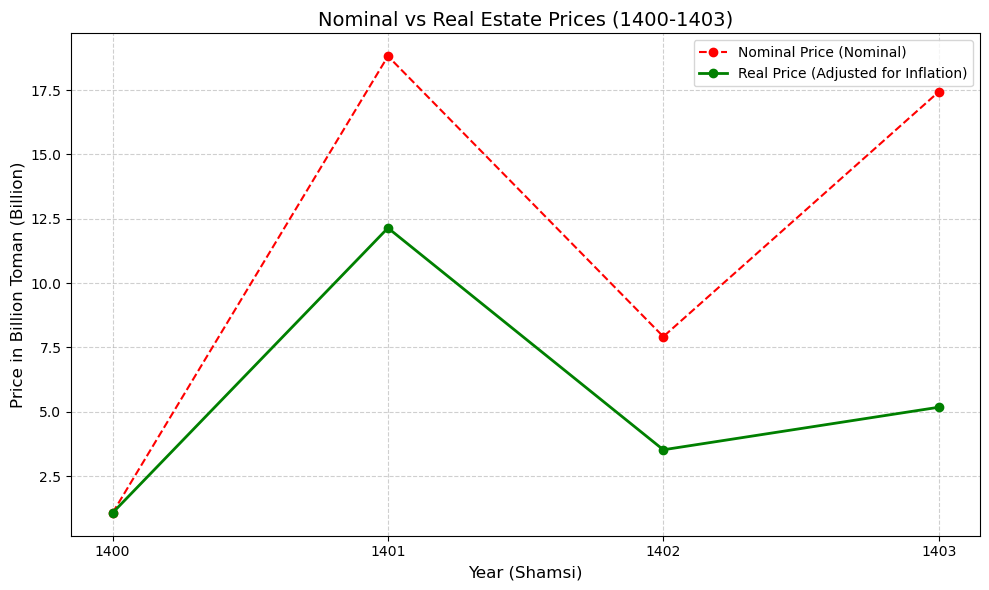

In [2]:
import matplotlib.pyplot as plt

# حذف سال‌های بدون داده
plot_data = result.dropna(subset=['Real_Price'])

plt.figure(figsize=(10, 6))

# رسم قیمت اسمی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['price_value'] / 1e9,
    marker='o',
    color='red',
    linestyle='--',
    label='Nominal Price (Nominal)',
)

# رسم قیمت حقیقی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['Real_Price'] / 1e9,
    marker='o',
    color='green',
    linewidth=2,
    label='Real Price (Adjusted for Inflation)',
)

plt.title('Nominal vs Real Estate Prices (1400-1403)', fontsize=14)
plt.xlabel('Year (Shamsi)', fontsize=12)
plt.ylabel('Price in Billion Toman (Billion)', fontsize=12)
plt.xticks(plot_data['Year_Shamsi'].astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()

In [3]:
import jdatetime
import pandas as pd


# ۱. تعریف توابع پایپ‌لاین
def clean_columns(df):
    df.columns = df.columns.str.strip()
    return df


def convert_to_shamsi(df):
    df["created_at_month"] = pd.to_datetime(
        df["created_at_month"], errors="coerce"
    )

    def get_shamsi_year(dt):
        if pd.isna(dt):
            return pd.NA
        return jdatetime.date.fromgregorian(
            year=dt.year, month=dt.month, day=dt.day
        ).year

    # محاسبه سال شمسی 
    unique_dates = df["created_at_month"].dropna().unique()
    date_to_shamsi_year = {
        d: get_shamsi_year(pd.Timestamp(d)) for d in unique_dates
    }

    df["Year_Shamsi"] = (
        df["created_at_month"].map(date_to_shamsi_year).astype("Int64")
    )
    return df


def add_real_price(df, inflation_indices):
    inflation_series = df["Year_Shamsi"].map(inflation_indices).fillna(1.0)
    df["Real_Price"] = df["price_value"] / inflation_series
    return df


# داده‌های ورودی
inflation_indices = {1400: 1.0, 1401: 1.55, 1402: 2.25, 1403: 3.37}

df = pd.read_csv("Divar.csv", low_memory=False)

# اجرای پایپ‌لاین با استفاده از میانه (median) به جای میانگین
final_analysis = (
    df.pipe(clean_columns)
    .pipe(convert_to_shamsi)
    .pipe(add_real_price, inflation_indices=inflation_indices)
    .groupby("Year_Shamsi", as_index=False)[["price_value", "Real_Price"]]
    .median()  # تغییر به میانه برای خنثی‌کردن داده‌های پرت
)

# ترکیب با جدول سال‌ها (نمایش سال‌های خالی)
all_years = pd.DataFrame({"Year_Shamsi": range(1400, 1406)})
result = pd.merge(all_years, final_analysis, on="Year_Shamsi", how="left")

# تنظیم نمایش اعداد 
pd.set_option(
    "display.float_format",
    lambda x: f"{x / 1e9:.2f}B" if pd.notnull(x) else "NaN",
)

result = result[result['Year_Shamsi'].between(1400, 1403)]

print(result)

   Year_Shamsi  price_value  Real_Price
0         1400        1.20B       1.20B
1         1401        2.33B       1.50B
2         1402        2.75B       1.22B
3         1403        2.85B       0.85B


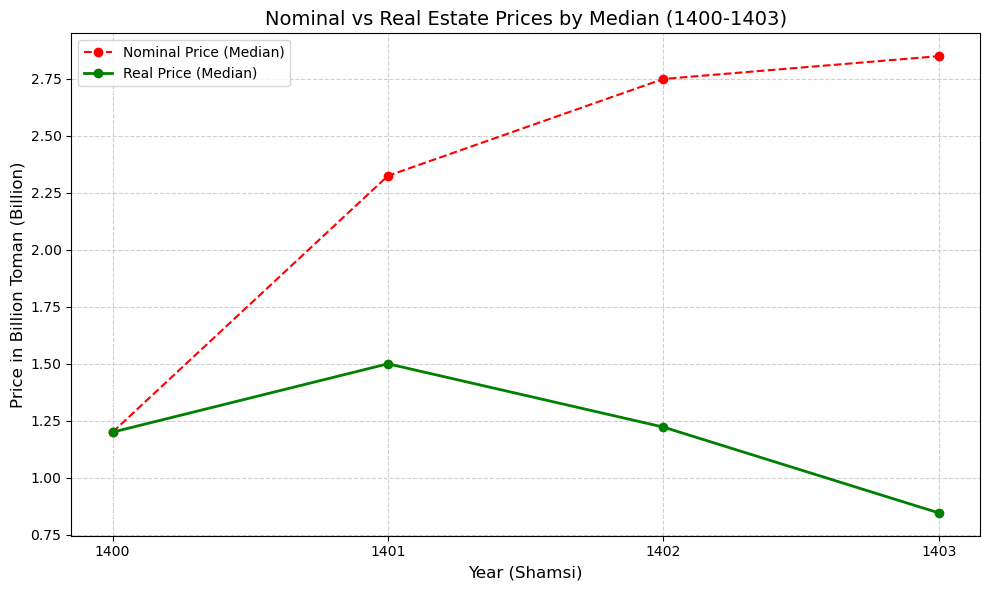

In [10]:
import matplotlib.pyplot as plt

# حذف سال‌های بدون داده
plot_data = result.dropna(subset=['Real_Price'])

plt.figure(figsize=(10, 6))

# رسم میانه قیمت اسمی و حقیقی
plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['price_value'] / 1e9,
    marker='o',
    color='red',
    linestyle='--',
    label='Nominal Price (Median)',
)

plt.plot(
    plot_data['Year_Shamsi'],
    plot_data['Real_Price'] / 1e9,
    marker='o',
    color='green',
    linewidth=2,
    label='Real Price (Median)',
)

plt.title('Nominal vs Real Estate Prices by Median (1400-1403)', fontsize=14)
plt.xlabel('Year (Shamsi)', fontsize=12)
plt.ylabel('Price in Billion Toman (Billion)', fontsize=12)
plt.xticks(plot_data['Year_Shamsi'].astype(int))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()